In [1]:
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
from astropy.io import fits
from galaxy_sidm.mock.residuals import pv_residuals, cube_residuals, cube_noise
from galaxy_sidm.mock.asymmetry import asymmetry_3d, fit_vsys

now = Path("/scratch/s4636708/aida/derived/martini")      # production: cell size x 1
wide = Path("/scratch/s4636708/aida/_test/kernel_width")   # test: cell size x 1.806 (MARTINI's TNG reader)
test_list = Path("/home2/s4636708/tmp/kernel_width_test.txt")
calibration = Path("/home2/s4636708/master_thesis_project/config/residual_calibration.yaml")
snap_z = {17: 5, 21: 4, 25: 3, 33: 2, 50: 1, 67: 0.5}

# the test galaxies and their calibration class
classes = {}
for cls, subs in yaml.safe_load(open(calibration))["CDM"]["z0.5"].items():
    for s in subs:
        classes[s] = cls
galaxies = []
for line in open(test_list):
    model, snap, sub, half = line.split()
    galaxies.append((model, snap_z[int(snap)], int(sub)))
galaxies

[('CDM', 0.5, 93157),
 ('CDM', 0.5, 78273),
 ('CDM', 0.5, 81373),
 ('CDM', 0.5, 84569),
 ('CDM', 0.5, 83331),
 ('CDM', 0.5, 72906),
 ('CDM', 0.5, 29145),
 ('CDM', 0.5, 69646)]

In [2]:
# the numbers that the classification uses, production cube (now) and wider kernels (wide).
# Reads every cube twice (residuals and asymmetry), so it takes a few minutes
rows = []
for model, z, sub in galaxies:
    for version, root in (("now", now), ("wide", wide)):
        g = root / f"z{z:g}" / model / f"gal_{sub:06d}"
        info = json.load(open(g / "info.json"))
        pv1, pv2 = pv_residuals(g)
        cube1, cube2 = cube_residuals(g)
        rows.append(dict(subID=sub, cls=classes[sub], version=version,
                         rings=info["nradii"], hole_rings=len(info.get("hole_rings_arcsec") or []),
                         start=max(v for v in info["pv_emission_start_arcsec"] if v is not None),
                         end=max(v for v in info["pv_emission_end_arcsec"] if v is not None),
                         V=info["V"], sigma=info["sigma"], VSYS=fit_vsys(g / "bbarolo"),
                         pv_res1=pv1, cube_res1=cube1, A_sq=asymmetry_3d(g).A_sq))
table = pd.DataFrame(rows)
table.round(3)

,subID,cls,version,rings,hole_rings,start,end,V,sigma,VSYS,pv_res1,cube_res1,A_sq
0,93157,discs,now,9,0,0.0,275.0,111.148,13.371,339.202,17.824,20.323,0.107
1,93157,discs,wide,9,0,0.0,275.0,112.318,13.597,339.722,17.850,19.819,0.103
2,78273,discs,now,26,0,0.0,770.0,178.213,12.221,342.298,26.452,24.896,0.154
3,78273,discs,wide,26,0,0.0,770.0,174.746,11.742,342.848,28.125,25.637,0.148
4,81373,discs,now,51,2,0.0,1535.0,168.706,8.475,349.138,20.217,27.006,0.269
5,81373,discs,wide,52,2,0.0,1540.0,167.476,8.998,349.003,20.482,26.656,0.261
6,84569,unsure_discs,now,39,2,0.0,1160.0,135.728,3.719,351.508,23.526,31.176,0.482
7,84569,unsure_discs,wide,39,2,0.0,1160.0,136.625,4.785,352.822,23.139,30.957,0.473
8,83331,unsure_discs,now,18,0,0.0,540.0,186.339,15.365,363.661,41.793,36.715,0.372
9,83331,unsure_discs,wide,19,0,0.0,550.0,167.226,12.589,357.906,47.850,37.950,0.363


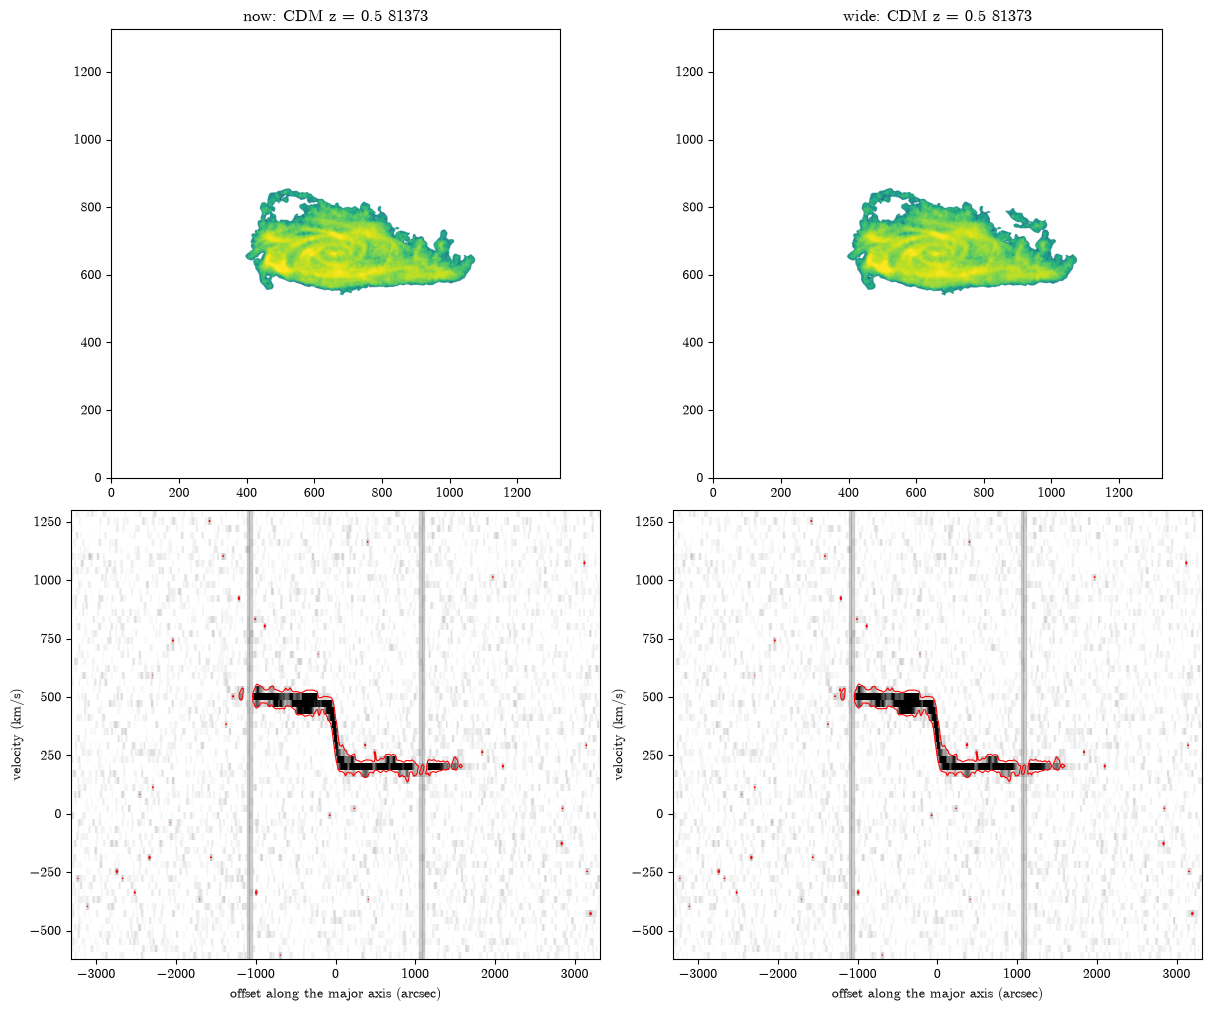

In [4]:
# one galaxy at a time: the 3-ring fit's moment-0 map (top) and the major-axis PV with its 3 sigma
# contour (bottom), production (left) and wider kernels (right), on the same colour scale.
# Grey bands on the PV: the final fit's hole rings, on both sides
sub_id = 81373
model, z = "CDM", 0.5

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
for col, (version, root) in enumerate((("now", now), ("wide", wide))):
    g = root / f"z{z:g}" / model / f"gal_{sub_id:06d}"
    info = json.load(open(g / "info.json"))
    mom0 = np.squeeze(fits.getdata(g / "bbarolo_3rings" / "maps" / "MOCK_0mom.fits"))
    pv_file = g / "bbarolo_3rings" / "pvs" / "MOCK_pv_a.fits"
    pv = np.nan_to_num(np.squeeze(fits.getdata(pv_file)))
    hp = fits.getheader(pv_file)
    offset = (np.arange(hp["NAXIS1"]) + 1 - hp["CRPIX1"]) * hp["CDELT1"] * 3600                  # deg -> arcsec
    velocity = (hp["CRVAL2"] + (np.arange(hp["NAXIS2"]) + 1 - hp["CRPIX2"]) * hp["CDELT2"]) / 1000   # m/s -> km/s
    if col == 0:   # colour scales from the production galaxy, used for both
        mom0_max = np.nanpercentile(mom0, 99)
        pv_max = np.percentile(pv, 99.5)
    axes[0, col].imshow(mom0, origin="lower", cmap="viridis", norm=LogNorm(vmin=mom0_max / 1000, vmax=mom0_max))
    axes[0, col].set_title(f"{version}: {model} z = {z:g} {sub_id}")
    axes[1, col].pcolormesh(offset, velocity, pv, cmap="Greys", vmin=0, vmax=pv_max)
    axes[1, col].contour(offset, velocity, pv / cube_noise(g), levels=[3], colors="red", linewidths=0.8)
    w = info["ring_width_arcsec"]
    for r in info.get("hole_rings_arcsec") or []:
        axes[1, col].axvspan(r - w / 2, r + w / 2, color="grey", alpha=0.3)
        axes[1, col].axvspan(-r - w / 2, -r + w / 2, color="grey", alpha=0.3)
    axes[1, col].set_xlabel("offset along the major axis (arcsec)")
    axes[1, col].set_ylabel("velocity (km/s)")
plt.show()

In [5]:
# the rotation velocity of the Tully-Fisher plots: v_flat by the SPARC rule (tables.v_flat), from the
# final fit's rings, production (now) and wider kernels (wide). nan: the curve is not flat
from galaxy_sidm.mock.tables import v_flat
from galaxy_sidm.mock.barolo import rings_file

vflat = pd.DataFrame([dict(subID=sub, cls=classes[sub],
                           now=v_flat(now / f"z{z:g}" / model / f"gal_{sub:06d}" / "bbarolo"),
                           wide=v_flat(wide / f"z{z:g}" / model / f"gal_{sub:06d}" / "bbarolo"))
                      for model, z, sub in galaxies])
vflat["change_percent"] = 100 * (vflat["wide"] / vflat["now"] - 1)
vflat.round(1)

,subID,cls,now,wide,change_percent
0,93157,discs,110.8,111.2,0.4
1,78273,discs,180.3,181.2,0.5
2,81373,discs,159.5,156.1,-2.1
3,84569,unsure_discs,172.8,172.5,-0.1
4,83331,unsure_discs,181.7,176.9,-2.7
5,72906,unsure_discs,154.3,NaN,NaN
6,29145,perturbed,NaN,NaN,NaN
7,69646,perturbed,225.7,NaN,NaN


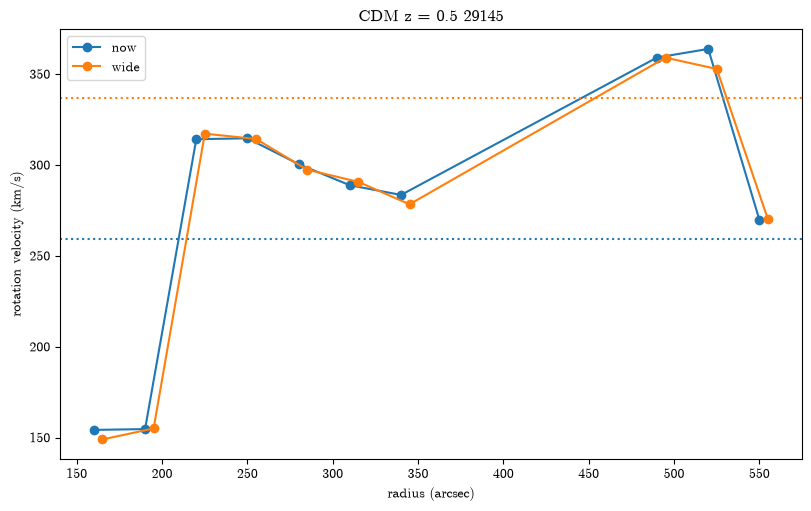

In [6]:
# one galaxy at a time: the final fit's rotation curve, production (now) and wider kernels (wide).
# Dotted: the table's V (mean of the highest ring velocity and the velocity where two neighbouring
# rings agree best). Dashed: v_flat from the cell above (not drawn when the curve is not flat)
sub_id = 29145
model, z = "CDM", 0.5

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
for version, root, colour in (("now", now, "C0"), ("wide", wide, "C1")):
    g = root / f"z{z:g}" / model / f"gal_{sub_id:06d}"
    rings = np.loadtxt(rings_file(g / "bbarolo"), comments="#", ndmin=2)
    ax.plot(rings[:, 1], rings[:, 2], "o-", color=colour, label=version)   # columns: RAD(arcs), VROT(km/s)
    ax.axhline(json.load(open(g / "info.json"))["V"], color=colour, ls=":")
    vf = v_flat(g / "bbarolo")
    if np.isfinite(vf):
        ax.axhline(vf, color=colour, ls="--")
ax.set_xlabel("radius (arcsec)")
ax.set_ylabel("rotation velocity (km/s)")
ax.set_title(f"{model} z = {z:g} {sub_id}")
ax.legend()
plt.show()